# Data Cleaning - Predictive Maintenance Dataset

Ebben a notebookban a Predictive Maintenance dataset adatbetöltését, első ellenőrzését, tisztítását és modellezésre előkészítését végezzük el.

A notebook célja:

- adatok betöltése,
- oszlopnevek egységesítése,
- hiányzó értékek és adattípusok ellenőrzése,
- duplikációk vizsgálata,
- célváltozó eloszlásának vizsgálata,
- osztály imbalance azonosítása,
- modellezéshez nem használható oszlopok kezelése,
- egyszerű feature engineering,
- kategorikus változók előkészítése,
- újrahasználható cleaning függvény kialakítása.

In [6]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Adatbetöltés

Első lépésként betöltjük a nyers CSV fájlt, majd ellenőrizzük az adathalmaz méretét, az első néhány sort és az oszlopok típusait.

In [9]:
DATA_PATH = Path("predictive_maintenance.csv")

In [68]:
df_raw = pd.read_csv(DATA_PATH)

df_raw.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [69]:
print(df_raw["Product ID"].unique)

<bound method Series.unique of 0       M14860
1       L47181
2       L47182
3       L47183
4       L47184
         ...  
9995    M24855
9996    H39410
9997    M24857
9998    H39412
9999    M24859
Name: Product ID, Length: 10000, dtype: object>


In [11]:
print(f"Sorok száma: {df_raw.shape[0]}")
print(f"Oszlopok száma: {df_raw.shape[1]}")

Sorok száma: 10000
Oszlopok száma: 10


In [12]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


A dataset 10 000 sort és 10 oszlopot tartalmaz. Az adatok között megtalálhatók azonosító jellegű mezők, kategorikus változók, numerikus gépi működési paraméterek, valamint a célváltozó.

Megállapítás: mindegyik oszlopnak helyes az adattípusa, egyik oszlop se taralmaz üres értékeket

A modellezési feladat szempontjából a `Target` oszlop lesz a bináris célváltozó, amely azt jelöli, hogy történt-e meghibásodás.

## 2. Oszlopnevek egységesítése

A nyers oszlopnevek tartalmaznak szóközöket, nagybetűket és mértékegységeket. A későbbi modellezés és függvényesítés érdekében az oszlopneveket egységes, Python-barát formátumra alakítjuk.

In [13]:
df_raw.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Target',
 'Failure Type']

In [14]:
df = df_raw.copy()

df = df.rename(columns={
    "UDI": "udi",
    "Product ID": "product_id",
    "Type": "type",
    "Air temperature [K]": "air_temperature_k",
    "Process temperature [K]": "process_temperature_k",
    "Rotational speed [rpm]": "rotational_speed_rpm",
    "Torque [Nm]": "torque_nm",
    "Tool wear [min]": "tool_wear_min",
    "Target": "target",
    "Failure Type": "failure_type"
})

df.head()

,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,target,failure_type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [16]:
df.columns.tolist()

['udi',
 'product_id',
 'type',
 'air_temperature_k',
 'process_temperature_k',
 'rotational_speed_rpm',
 'torque_nm',
 'tool_wear_min',
 'target',
 'failure_type']

## 3. Hiányzó értékek vizsgálata

A hiányzó értékek ellenőrzése fontos lépés, mert a legtöbb gépi tanulási modell nem tud közvetlenül hiányzó értékekkel dolgozni. Ilyen esetben imputálásra vagy rekordtörlésre lenne szükség.

In [17]:
missing_values = df.isna().sum().sort_values(ascending=False)

missing_values

udi                      0
product_id               0
type                     0
air_temperature_k        0
process_temperature_k    0
rotational_speed_rpm     0
torque_nm                0
tool_wear_min            0
target                   0
failure_type             0
dtype: int64

A vizsgálat alapján a datasetben nincs hiányzó érték, ezért imputálásra nincs szükség.

## 4. Duplikált sorok vizsgálata

A teljesen duplikált sorok torzíthatják a modell tanítását, ezért ellenőrizzük, hogy található-e ismétlődő rekord az adathalmazban.

In [18]:
duplicate_count = df.duplicated().sum()

print(f"Teljesen duplikált sorok száma: {duplicate_count}")

Teljesen duplikált sorok száma: 0


## 5. Azonosító jellegű oszlopok vizsgálata

A dataset tartalmaz olyan oszlopokat, amelyek azonosítóként szolgálnak. Ezek általában nem hordoznak általánosítható prediktív információt, ezért a modellezésből ki kell zárni őket.

In [19]:
id_summary = pd.DataFrame({
    "unique_values": df[["udi", "product_id"]].nunique(),
    "total_rows": len(df)
})

id_summary

,unique_values,total_rows
udi,10000,10000
product_id,10000,10000


## 6. Célváltozó eloszlásának vizsgálata

A `target` oszlop jelöli, hogy történt-e géphiba:

- `0`: nincs meghibásodás,
- `1`: meghibásodás történt.

A célváltozó eloszlásának vizsgálata különösen fontos, mert az erősen kiegyensúlyozatlan célváltozó befolyásolja a modellválasztást, a tanítást és a kiértékelést.

In [20]:
target_counts = df["target"].value_counts().sort_index()
target_ratios = df["target"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "ratio_percent": target_ratios.round(2)
})

target_summary

,count,ratio_percent
target,,
0,9661,96.61
1,339,3.39


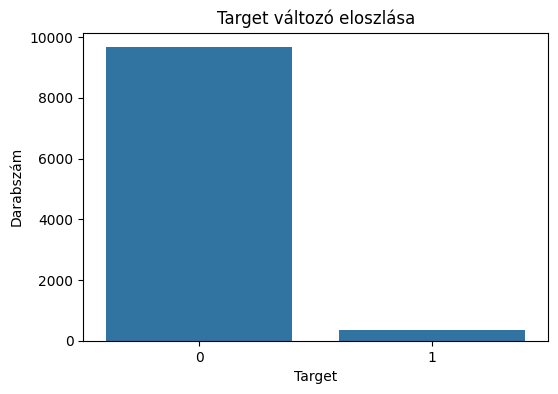

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")
plt.title("Target változó eloszlása")
plt.xlabel("Target")
plt.ylabel("Darabszám")
plt.show()

A célváltozó erősen kiegyensúlyozatlan. A meghibásodás nélküli esetek aránya körülbelül 96,61%, míg a meghibásodások aránya csak körülbelül 3,39%.

Ez azt jelenti, hogy a sima accuracy metrika félrevezető lehet, mivel egy olyan modell is magas pontosságot érhetne el, amely szinte mindig a többségi osztályt prediktálja. Emiatt a későbbi modellezés során olyan metrikák használata indokolt, mint a recall, precision, F1-score, ROC-AUC és PR-AUC.

## 7. Failure Type változó vizsgálata

A `failure_type` oszlop a meghibásodás típusát írja le. Mivel a projekt elsődleges célja a bináris hibapredikció, ezért a fő célváltozó a `target` lesz.

Fontos ellenőrizni, hogy a `failure_type` hogyan viszonyul a `target` változóhoz.

In [22]:
failure_counts = df["failure_type"].value_counts()

failure_counts

failure_type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

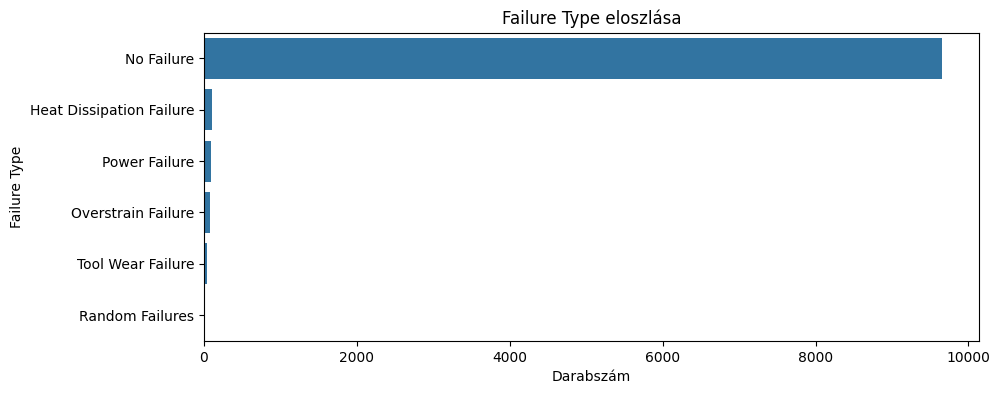

In [23]:
plt.figure(figsize=(10, 4))
sns.countplot(
    data=df,
    y="failure_type",
    order=df["failure_type"].value_counts().index
)
plt.title("Failure Type eloszlása")
plt.xlabel("Darabszám")
plt.ylabel("Failure Type")
plt.show()

In [24]:
failure_target_crosstab = pd.crosstab(df["target"], df["failure_type"])

failure_target_crosstab

failure_type,Heat Dissipation Failure,No Failure,Overstrain Failure,Power Failure,Random Failures,Tool Wear Failure
target,,,,,,
0,0,9643,0,0,18,0
1,112,9,78,95,0,45


In [25]:
inconsistent_cases = df[
    ((df["target"] == 0) & (df["failure_type"] != "No Failure")) |
    ((df["target"] == 1) & (df["failure_type"] == "No Failure"))
]

print(f"Inkonzisztensnek tűnő esetek száma: {len(inconsistent_cases)}")

inconsistent_cases.head()

Inkonzisztensnek tűnő esetek száma: 27


,udi,product_id,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,target,failure_type
1221,1222,M16081,M,297.0,308.3,1399,46.4,132,0,Random Failures
1302,1303,L48482,L,298.6,309.8,1505,45.7,144,0,Random Failures
1437,1438,H30851,H,298.8,309.9,1439,45.2,40,1,No Failure
1748,1749,H31162,H,298.4,307.7,1626,31.1,166,0,Random Failures
2072,2073,L49252,L,299.6,309.5,1570,35.5,189,0,Random Failures


A `target` és `failure_type` változók összevetése során néhány inkonzisztensnek tűnő eset található. Például előfordul, hogy a `target` értéke 0, de a `failure_type` nem `No Failure`, illetve olyan eset is van, ahol a `target` értéke 1, de a `failure_type` értéke `No Failure`.

A bináris modellezési feladatban a `target` mezőt tekintjük elsődleges célváltozónak. A `failure_type` változót nem használjuk magyarázó változóként, mert közvetlenül kapcsolódik a célváltozóhoz, így használata adat-szivárgást okozhatna.

## 8. Numerikus változók vizsgálata

A modellezéshez használt numerikus változók gépi működési paramétereket írnak le. Ellenőrizzük ezek alapstatisztikáit és értéktartományait.

In [26]:
numeric_columns = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
air_temperature_k,10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
process_temperature_k,10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
rotational_speed_rpm,10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
torque_nm,10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
tool_wear_min,10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


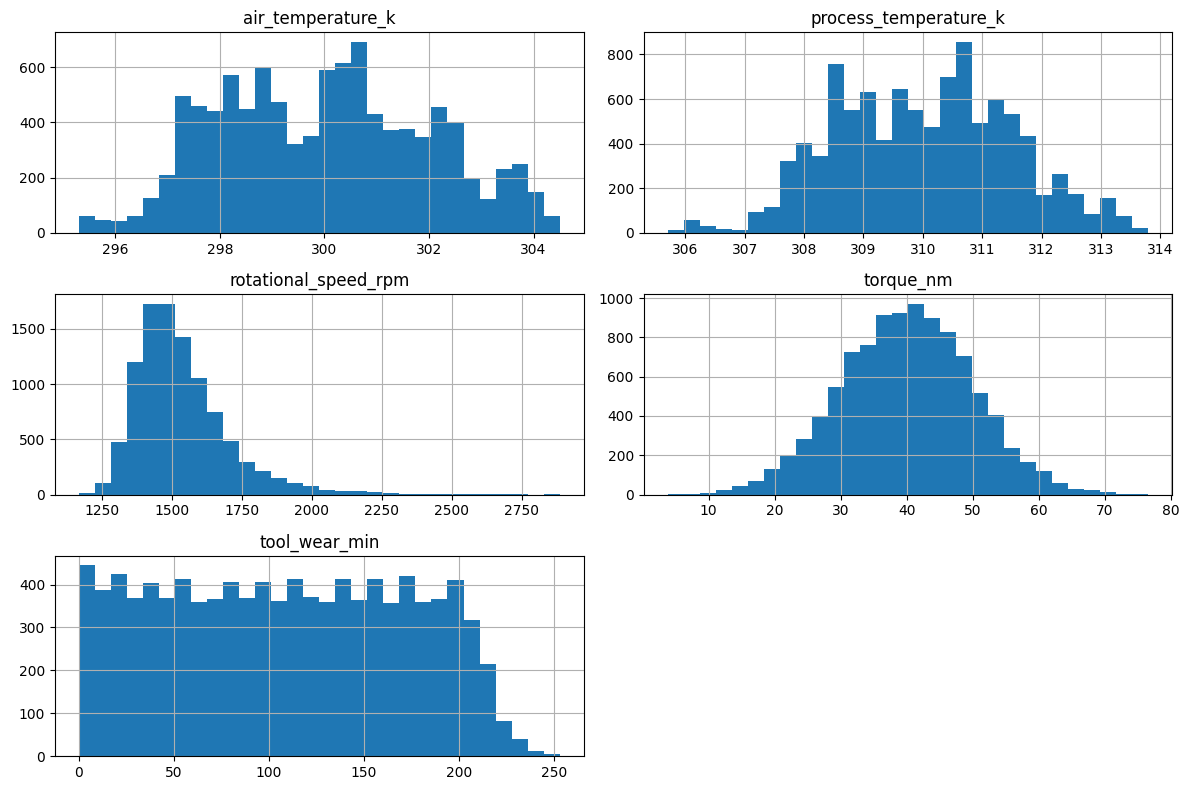

In [27]:
df[numeric_columns].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

A numerikus változók értéktartományai első ránézésre életszerűek. Extrém hiányzó vagy hibás érték nem látható. A későbbi modellezési lépésekben egyes modellek, például a logisztikus regresszió vagy az SVM esetén skálázásra is szükség lehet.

## 9. Kategorikus változó vizsgálata

A `type` változó a termék típusát jelöli. Ez kategorikus változó, ezért a legtöbb modellhez numerikus formára kell alakítani.

In [28]:
type_counts = df["type"].value_counts()

type_counts

type
L    6000
M    2997
H    1003
Name: count, dtype: int64

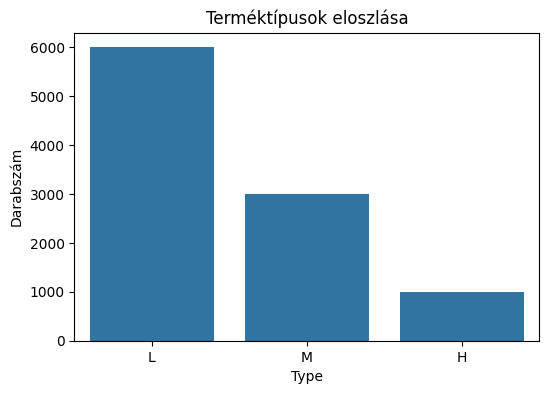

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)
plt.title("Terméktípusok eloszlása")
plt.xlabel("Type")
plt.ylabel("Darabszám")
plt.show()

## 10. Feature engineering

A meglévő hőmérsékleti változókból létrehozunk egy új változót, amely a folyamat hőmérséklete és a levegő hőmérséklete közötti különbséget méri.

Ez a változó üzletileg is értelmezhető, mivel a gép működése közbeni hőterhelés hasznos információ lehet a meghibásodás előrejelzésében.

In [32]:
df["temperature_difference_k"] = (
    df["process_temperature_k"] - df["air_temperature_k"]
)

df[[
    "air_temperature_k",
    "process_temperature_k",
    "temperature_difference_k"
]].head()

,air_temperature_k,process_temperature_k,temperature_difference_k
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [33]:
df["temperature_difference_k"].describe()

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: temperature_difference_k, dtype: float64

## 11. Modellezési dataset előkészítése

A modellezéshez eltávolítjuk azokat az oszlopokat, amelyeket nem szeretnénk prediktorként használni.

Eltávolított oszlopok:

- `udi`: egyedi azonosító,
- `product_id`: termékazonosító,
- `failure_type`: a célváltozóhoz közvetlenül kapcsolódó hibakategória, ezért leakage-veszélyes.

In [44]:
columns_to_drop = [
    "udi",
    "product_id",
    "failure_type"
]

df_model = df.drop(columns=columns_to_drop)

df_model.head()

,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,target,temperature_difference_k
0,M,298.1,308.6,1551,42.8,0,0,10.5
1,L,298.2,308.7,1408,46.3,3,0,10.5
2,L,298.1,308.5,1498,49.4,5,0,10.4
3,L,298.2,308.6,1433,39.5,7,0,10.4
4,L,298.2,308.7,1408,40.0,9,0,10.5


A `type` kategorikus változót one-hot encoding segítségével alakítjuk át. Így külön bináris oszlop jön létre minden terméktípushoz.

A `type` kategorikus változót one-hot encoding segítségével alakítottuk át numerikus változókká.

Mivel a `type` változó három kategóriát tartalmaz (`L`, `M`, `H`), elegendő két dummy változót létrehozni. A harmadik kategória referencia kategóriaként értelmezhető. Ez csökkenti a redundanciát, és különösen a logisztikus regresszió esetén segít elkerülni a dummy variable trap problémát.

In [45]:
df_model = pd.get_dummies(
    df_model,
    columns=["type"],
    drop_first=True,
    dtype=int
)

df_model.head()

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,target,temperature_difference_k,type_L,type_M
0,298.1,308.6,1551,42.8,0,0,10.5,0,1
1,298.2,308.7,1408,46.3,3,0,10.5,1,0
2,298.1,308.5,1498,49.4,5,0,10.4,1,0
3,298.2,308.6,1433,39.5,7,0,10.4,1,0
4,298.2,308.7,1408,40.0,9,0,10.5,1,0


In [37]:
df_model.columns.tolist()

['air_temperature_k',
 'process_temperature_k',
 'rotational_speed_rpm',
 'torque_nm',
 'tool_wear_min',
 'target',
 'temperature_difference_k',
 'type_H',
 'type_L',
 'type_M']

In [38]:
print("Végső modellezési dataset mérete:")
print(df_model.shape)

print("\nHiányzó értékek száma:")
print(df_model.isna().sum().sum())

print("\nDuplikált sorok száma:")
print(df_model.duplicated().sum())

df_model.head()

Végső modellezési dataset mérete:
(10000, 10)

Hiányzó értékek száma:
0

Duplikált sorok száma:
0


,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,target,temperature_difference_k,type_H,type_L,type_M
0,298.1,308.6,1551,42.8,0,0,10.5,0,0,1
1,298.2,308.7,1408,46.3,3,0,10.5,0,1,0
2,298.1,308.5,1498,49.4,5,0,10.4,0,1,0
3,298.2,308.6,1433,39.5,7,0,10.4,0,1,0
4,298.2,308.7,1408,40.0,9,0,10.5,0,1,0


## 12. Modellezési input és célváltozó ellenőrzése

In [64]:
X = df_model.drop(columns=["target"])
y = df_model["target"]

print("X mérete:", X.shape)
print("y mérete:", y.shape)

X mérete: (10000, 8)
y mérete: (10000,)


In [40]:
X.head()

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,temperature_difference_k,type_H,type_L,type_M
0,298.1,308.6,1551,42.8,0,10.5,0,0,1
1,298.2,308.7,1408,46.3,3,10.5,0,1,0
2,298.1,308.5,1498,49.4,5,10.4,0,1,0
3,298.2,308.6,1433,39.5,7,10.4,0,1,0
4,298.2,308.7,1408,40.0,9,10.5,0,1,0


In [41]:
y.value_counts(normalize=True).round(4)

target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

## 13. Imbalance azonosítása



In [46]:
target_counts = df["target"].value_counts().sort_index()
target_ratios = df["target"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "ratio_percent": target_ratios.round(2)
})

target_summary

,count,ratio_percent
target,,
0,9661,96.61
1,339,3.39


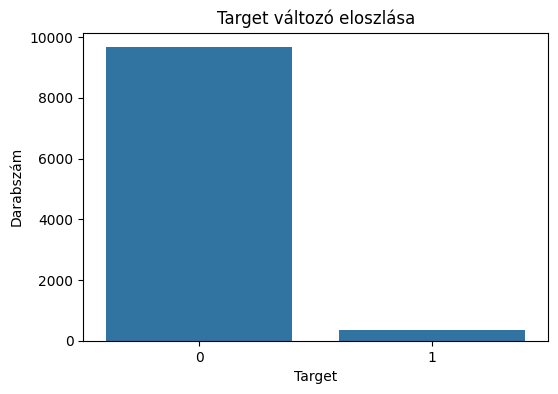

In [47]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")
plt.title("Target változó eloszlása")
plt.xlabel("Target")
plt.ylabel("Darabszám")
plt.show()

A célváltozó erősen kiegyensúlyozatlan. A meghibásodás nélküli esetek aránya körülbelül 96,61%, míg a meghibásodások aránya körülbelül 3,39%.

Ez alapján a későbbi train-test split és modellezési lépések során figyelni kell arra, hogy a kisebbségi osztály megfelelően reprezentálva legyen. Az imbalance konkrét kezelése nem ebben a cleaning notebookban történik, hanem a későbbi modellezési vagy adatfelosztási lépésekben.

## 14. Cleaning pipeline függvényesítése

A fenti lépéseket függvényekbe szervezzük, hogy a későbbi modellezési notebookokban ugyanaz az előfeldolgozási logika újrahasználható legyen.

In [48]:
def rename_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    column_mapping = {
        "UDI": "udi",
        "Product ID": "product_id",
        "Type": "type",
        "Air temperature [K]": "air_temperature_k",
        "Process temperature [K]": "process_temperature_k",
        "Rotational speed [rpm]": "rotational_speed_rpm",
        "Torque [Nm]": "torque_nm",
        "Tool wear [min]": "tool_wear_min",
        "Target": "target",
        "Failure Type": "failure_type"
    }
    
    return df.rename(columns=column_mapping)

In [55]:
def validate_cleaned_data(df: pd.DataFrame) -> None:
    """
    Alapvető validációkat futtat a tisztított oszlopnevű adaton.
    Hibát dob, ha hiányzik szükséges oszlop, hibás target érték van,
    vagy nem várt kategória jelenik meg.
    """
    required_columns = [
        "udi",
        "product_id",
        "type",
        "air_temperature_k",
        "process_temperature_k",
        "rotational_speed_rpm",
        "torque_nm",
        "tool_wear_min",
        "target",
        "failure_type"
    ]
    
    missing_columns = [col for col in required_columns if col not in df.columns]
    
    if missing_columns:
        raise ValueError(f"Hiányzó oszlopok: {missing_columns}")
    
    allowed_target_values = {0, 1}
    actual_target_values = set(df["target"].dropna().unique())
    
    if not actual_target_values.issubset(allowed_target_values):
        raise ValueError(f"Nem várt target értékek: {actual_target_values}")
    
    allowed_type_values = {"L", "M", "H"}
    actual_type_values = set(df["type"].dropna().unique())
    
    if not actual_type_values.issubset(allowed_type_values):
        raise ValueError(f"Nem várt type kategóriák: {actual_type_values}")
    
    if df.isna().sum().sum() > 0:
        raise ValueError("A dataset hiányzó értékeket tartalmaz.")

In [ ]:

def create_target_summary(df: pd.DataFrame, target_column: str = "target") -> pd.DataFrame:
    """
    Összefoglaló táblát készít a célváltozó eloszlásáról.
    Ez az imbalance azonosítására szolgál, de nem végez imbalance-kezelést.
    """
    target_counts = df[target_column].value_counts().sort_index()
    target_ratios = df[target_column].value_counts(normalize=True).sort_index() * 100
    
    target_summary = pd.DataFrame({
        "count": target_counts,
        "ratio_percent": target_ratios.round(2)
    })
    
    return target_summary

In [50]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    df["temperature_difference_k"] = (
        df["process_temperature_k"] - df["air_temperature_k"]
    )
    
    return df

In [51]:
def prepare_modeling_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    columns_to_drop = [
        "udi",
        "product_id",
        "failure_type"
    ]
    
    df = df.drop(columns=columns_to_drop)
    
    df = pd.get_dummies(
        df,
        columns=["type"],
        drop_first=True,
        dtype=int
    )
    
    return df

In [52]:
def clean_predictive_maintenance_data(data_path: str | Path) -> pd.DataFrame:
    df_raw = pd.read_csv(data_path)
    
    df_cleaned = rename_columns(df_raw)
    
    validate_cleaned_data(df_cleaned)
    
    df_cleaned = add_engineered_features(df_cleaned)
    
    df_model = prepare_modeling_dataset(df_cleaned)
    
    return df_model

In [65]:
#Teszt
df_model_final = clean_predictive_maintenance_data(DATA_PATH)

df_model_final.head()


,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,target,temperature_difference_k,type_L,type_M
0,298.1,308.6,1551,42.8,0,0,10.5,0,1
1,298.2,308.7,1408,46.3,3,0,10.5,1,0
2,298.1,308.5,1498,49.4,5,0,10.4,1,0
3,298.2,308.6,1433,39.5,7,0,10.4,1,0
4,298.2,308.7,1408,40.0,9,0,10.5,1,0


In [63]:
print("Modellezési dataset mérete:", df_model_final.shape)
print("Hiányzó értékek száma:", df_model_final.isna().sum().sum())
print("Duplikált sorok száma:", df_model_final.duplicated().sum())

print("\nVégső oszlopok:")
display(df_model_final.columns.tolist())

print("\nTarget eloszlás:")
display(create_target_summary(df_model_final))

Modellezési dataset mérete: (10000, 9)
Hiányzó értékek száma: 0
Duplikált sorok száma: 0

Végső oszlopok:


['air_temperature_k',
 'process_temperature_k',
 'rotational_speed_rpm',
 'torque_nm',
 'tool_wear_min',
 'target',
 'temperature_difference_k',
 'type_L',
 'type_M']


Target eloszlás:


,count,ratio_percent
target,,
0,9661,96.61
1,339,3.39
